\*Doble click para ver comandos de LaTex*
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\had}[1]{  \frac{\ket{0}#1\ket{1}}{\sqrt{2}} } $

*Asegurate de tener instalado estas dependencias en tu noteboook*

In [1]:
%%capture
# -------------------------------------------------------------
# Instalamos dependencias y paquetes
# -------------------------------------------------------------

!pip install qiskit                         #Qiskit
!pip install qiskit-aer                     #simulador cuántico local
!pip install pylatexenc                     #renderiza latex dentro de gráficos
#!pip install qiskit-ibm-runtime            #Solo para ejecutar en hardware real

# Si tienes problemas para ejecutar luego de haber instalado, restaura la sesión: Runtime > Restart session

## Ejercicio 2.30 - Wong

Haz los cálculos para demostrar que

(a). $H\ket{-}=\ket{1}$

(b). $H\ket{-i}=e^{-i\pi/4}\ket{i} \equiv \ket{i}$


**Sol.**

(a).
\begin{align*}
H\ket{-} &= H\left(\frac{\ket{0}-\ket{1}}{\sqrt{2}}\right) \\
         &= \frac{1}{\sqrt{2}}\left(H\ket{0}-H\ket{1}\right) \\
         &= \frac{1}{\sqrt{2}}\left( \had{+} - \had{-}\right) \\
         &= \frac{1}{\sqrt{2}}\left( \frac{2\ket{1}}{\sqrt{2}}\right) \\
         &= \ket{1}
\end{align*}

(b).
\begin{align*}
H\ket{-i} &= H\left( \had{-i} \right) = \frac{1}{\sqrt{2}}\left(H\ket{0}-iH\ket{1}\right) \\
          &= \frac{1}{\sqrt{2}}\left( \had{+} - i(\had{-})\right) = \frac{1}{\sqrt{2}}\left( \frac{1-i}{\sqrt{2}}\ket{0}+\frac{1+i}{\sqrt{2}}\ket{1}\right) \quad (\star2)\\
          &= \frac{1}{\sqrt{2}}\left( e^{-i\pi/4}\ket{0}+e^{i\pi/4}\ket{1}\right) = \frac{e^{-i\pi/4}}{\sqrt{2}}\left( \ket{0}+e^{i\pi/2}\ket{1}\right) \\
          &= \frac{e^{-i\pi/4}}{\sqrt{2}}\left( \ket{0}+i\ket{1}\right) = e^{-i\pi/4}\ket{i} \\
          & \equiv \ket{i} \\
\end{align*}

Note que $e^{-i\pi/4}$ actua como una fase global sobre $\ket{1}$, por tanto por eso podemos decir que $H\ket{-i} \equiv \ket{i}$

## 3. Verificación con Qiskit


In [34]:
# -------------------------------------------------------------
# Ejercicio: 2.30 (a) Wong
# -------------------------------------------------------------

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np

#Creamos un circuito con un solo qubit
qc = QuantumCircuit(1)

#Inicializamos el estado del qubit a |->
alpha = 1/np.sqrt(2)
beta = -1/np.sqrt(2)
qc.initialize([alpha, beta], 0)

#Añadimos una compuerta H
qc.h(0)

#Evaluamos el estado del qubit
state0 = Statevector.from_instruction(qc)

#Visualizamos el estado
print('Estado del qubit: ', state0.data)


Estado del qubit:  [0.+0.j 1.+0.j]


In [35]:
# -------------------------------------------------------------
# Ejercicio: 2.30 (b) Wong
# -------------------------------------------------------------

import matplotlib.pyplot as plt

#Inicializamos el estado del qubit a |-i>
alpha = 1/np.sqrt(2)
beta = -1j/np.sqrt(2)             #note que -1j es complejo
qc.initialize([alpha, beta], 0)

#Añadimos una compuerta H
qc.h(0)

#Evaluamos el estado del qubit
state1 = Statevector.from_instruction(qc)

#Visualizamos el estado
print('Estado del qubit: ', state1.data)


Estado del qubit:  [0.5-0.5j 0.5+0.5j]


Note que el resultado `[0.5-0.5j 0.5+0.5j]` es visualmente diferente a lo que esperabamos, es decir $\ket{i}$, sin embargo en la línea $(\star 2)$ de la prueba del punto **(b.)** teniamos que
$
H\ket{-i} = \frac{1}{\sqrt{2}}\left( \frac{1-i}{\sqrt{2}}\ket{0}+\frac{1+i}{\sqrt{2}}\ket{1}\right)
$ si simplificamos, obtenemos que $
\frac{1}{2}\left( (1-i)\ket{0}+(1+i)\ket{1}\right) = \myvector{\frac{1}{2} - \frac{1}{2}i\\ \frac{1}{2} + \frac{1}{2}i}.
$

Que es el mismo resultado que retornó Qiskit, esto quiere decir que el resultado lo arroja con toda la fase global $e^{-i\pi/4}$. Sin embargo, en la visualización se muestra que efectivamente es equivalente a $\ket{i}$.

## 4. Visualización


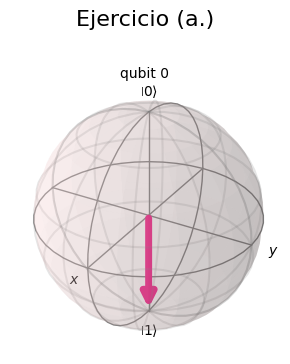

In [39]:
# Visualizamos estados en la esfera de Bloch
plot_bloch_multivector(state0, title='Ejercicio (a.)', figsize=(3, 3))

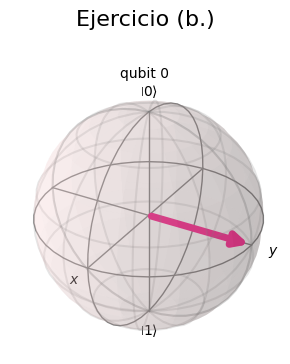

In [38]:
plot_bloch_multivector(state1, title='Ejercicio (b.)', figsize=(3, 3))

## 5. Conclusión

El ejercicio (b.) nos muestra que es importante conocer las equivalencias derivadas de una fase global, así es facil comprender el resultado obtenido al evaluar el estado vs la visualización gráfica en la esfera de Bloch.

## 5. Referencias
### Referencias
1. D. McMahon. Quantum Computing Explained. IEEE Press. Wiley, 2008.
2. Thomas G. Wong. Introduction to Classical and Quantum Computing. University of Texas Rio
Grande Valley, 2021.
